#### Imports and fetching data 

In [ ]:
import pandas as pd
from companies import companies
import numpy as np
from datetime import timedelta, datetime
import matplotlib.pyplot as plt
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns
from pandas_datareader import data as pdr
import yfinance as yf
import time
yf.pdr_override()

holdings = pd.read_excel("BUFC_May_2025_Allocations.xlsx", sheet_name=0) 
holdings = holdings[:-2]
holdings = holdings.drop(holdings.iloc[1].name)
holdings = holdings.drop(holdings.iloc[14].name)
holdings.loc[holdings.index[0], 'Current Price'] = 1.0
holdings.loc[holdings.index[0], 'Current Value'] = holdings.loc[holdings.index[0], 'Total Cost Basis']
holdings.loc[holdings.index[0], 'Average Cost Basis'] = 1.0
holdings = holdings.rename(columns={"Unnamed: 0": "Company"})
holdings["Ticker"] = holdings["Company"].str.extract(r":([A-Z]+)\)")
holdings = holdings.reset_index()
holdings = holdings.drop('index', axis=1)

sector_allocations = pd.read_excel("BUFC_May_2025_Allocations.xlsx", sheet_name=1) 
sector_allocations.loc[sector_allocations.index[-1], '% of Fund'] = 1.0

In [ ]:
from polygon import RESTClient
from datetime import datetime
from dateutil.relativedelta import relativedelta

client = RESTClient("FnlGiHgIUqRipoOra1mzJQpYJTrMUqTS") # don't share this pls 

end_date = datetime.today()
start_date = pd.to_datetime("2025-01-01")
start_str = start_date.strftime("%Y-%m-%d")
end_str = end_date.strftime("%Y-%m-%d")

prices_data = pd.DataFrame()

for stock in companies:
    try:
        aggs = client.get_aggs(
            ticker=stock,
            multiplier=1,
            timespan="day",
            from_=start_str,
            to=end_str,
            adjusted=True,
            sort="asc",
            limit=120
        )
        temp_df = pd.DataFrame([{
            "date": datetime.utcfromtimestamp(a.timestamp / 1000).date(),
            stock: a.close
        } for a in aggs])

        temp_df.set_index("date", inplace=True)
        prices_data = prices_data.join(temp_df, how="outer") if not prices_data.empty else temp_df
    except Exception as e:
        print(f"Failed to fetch {stock}: {e}")
    time.sleep(15)

In [ ]:
#define new portfolio df 
columns = ['Ticker', 'shares', 'cost basis', 'current value', 'return', 'weights']
live_portfolio = pd.DataFrame(columns=columns)

latest_prices = prices_data.iloc[-1]

cash_row = holdings.iloc[0]
cash_amount = cash_row["Total Cost Basis"]

live_portfolio.loc[len(live_portfolio)] = [
    "SPAXX",           
    cash_amount,    
    cash_amount,            
    cash_amount,       
    0,                 
    0                   
]

for _, row in holdings.iloc[1:].iterrows(): 
    ticker = row["Ticker"]
    
    shares = row["Total Cost Basis"] / row["Average Cost Basis"]
    cost_basis = row["Total Cost Basis"]
    current_price = latest_prices[ticker]
    current_value = shares * current_price
    ret = (current_value - cost_basis) / cost_basis
    
    live_portfolio.loc[len(live_portfolio)] = [
        ticker, shares, cost_basis, current_value, ret, 0
    ]

portfolio_value = live_portfolio["current value"].sum()
live_portfolio["weights"] = live_portfolio["current value"] / portfolio_value

live_portfolio = live_portfolio.sort_values("weights", ascending=False).reset_index(drop=True)

#### Live portfolio analysis 

In [ ]:
live_portfolio

,Ticker,shares,cost basis,current value,return,weights
0,PSCT,2865.00,136144.80,126604.3500,-0.070076,0.106424
1,PSCI,933.00,86489.10,120515.6100,0.393420,0.101306
2,STEP,1495.00,44431.40,89027.2500,1.003701,0.074836
3,KBWR,1226.00,70776.98,71402.2400,0.008834,0.060021
4,PSCH,1680.00,69720.00,69745.2000,0.000361,0.058628
5,SPAXX,66121.67,66121.67,66121.6700,0.000000,0.055582
6,PSR,616.00,54904.08,57201.7600,0.041849,0.048084
7,RSPF,744.00,37051.20,55427.8512,0.495980,0.046593
8,EHC,425.00,41824.25,51369.7500,0.228229,0.043181
9,RSPG,650.00,44167.50,49081.5000,0.111258,0.041258


In [ ]:
print(f"Total portfolio value as of {end_date}: ${portfolio_value:,.2f}")

Total portfolio value as of 2025-05-19: $1,189,625.39


In [ ]:
start_date = "2025-01-01"
end_date = datetime.today().strftime("%Y-%m-%d")

client = RESTClient("FnlGiHgIUqRipoOra1mzJQpYJTrMUqTS")

aggs = client.get_aggs(
    ticker="IWM",
    multiplier=1,
    timespan="day",
    from_=start_date,
    to=end_date,
    adjusted=True,
    sort="asc",
    limit=5000
)

rut_df = pd.DataFrame([{
    "date": pd.to_datetime(a.timestamp, unit="ms"),
    "IWM": a.close
} for a in aggs])

rut_df['date'] = pd.to_datetime(rut_df['date'])
rut_df.set_index('date', inplace=True)
rut_df.rename(columns={'IWM': 'price'}, inplace=True)
rut_series = rut_df['price']

In [ ]:
tickers = list(prices_data.columns)  # use all tickers, including index ETFs

prices_data.index = pd.to_datetime(prices_data.index).normalize()
rut_series.index = pd.to_datetime(rut_series.index).normalize()

portfolio_returns = prices_data.pct_change().mean(axis=1)
benchmark_returns = rut_series.pct_change()
excess_returns = portfolio_returns - benchmark_returns

portfolio_cum = (1 + portfolio_returns.fillna(0)).cumprod()
benchmark_cum = (1 + benchmark_returns.fillna(0)).cumprod()
alpha_line = portfolio_cum - benchmark_cum

rolling_alpha = excess_returns.rolling(30).mean()

sectors = {'PSCI':'Index', 'PSCT':'Index', 'PSCM':'Index', 'PSCU':'Index',
        'RSPG':'Index', 'RSPF':'Index', 'MITK':'Tech','NXT':'Tech', 'PATK':
        'Industrials', 'PECO':'Real Estate', 'PUBM':'Tech', 'STEP':'Financial',
        'ENSG':'Healthcare', 'MODG':'Consumer','WINA':'Consumer', 'AGCO':'Industrials',
        'BMI':'Industrials', 'SKY':'Consumer', 'CVLT':'Tech', 'EHC':'Healthcare',
        'INMD':'Healthcare', 'PSR':'Index', 'KBWR':'Index', 'PSCC':'Index', 'PSCH':'Index'}

sector_map = {ticker: sectors[ticker] for ticker in tickers}
sector_excess = prices_data[tickers].pct_change().sub(benchmark_returns, axis=0)
sector_contributions = sector_excess.mean().groupby(sector_map).sum()

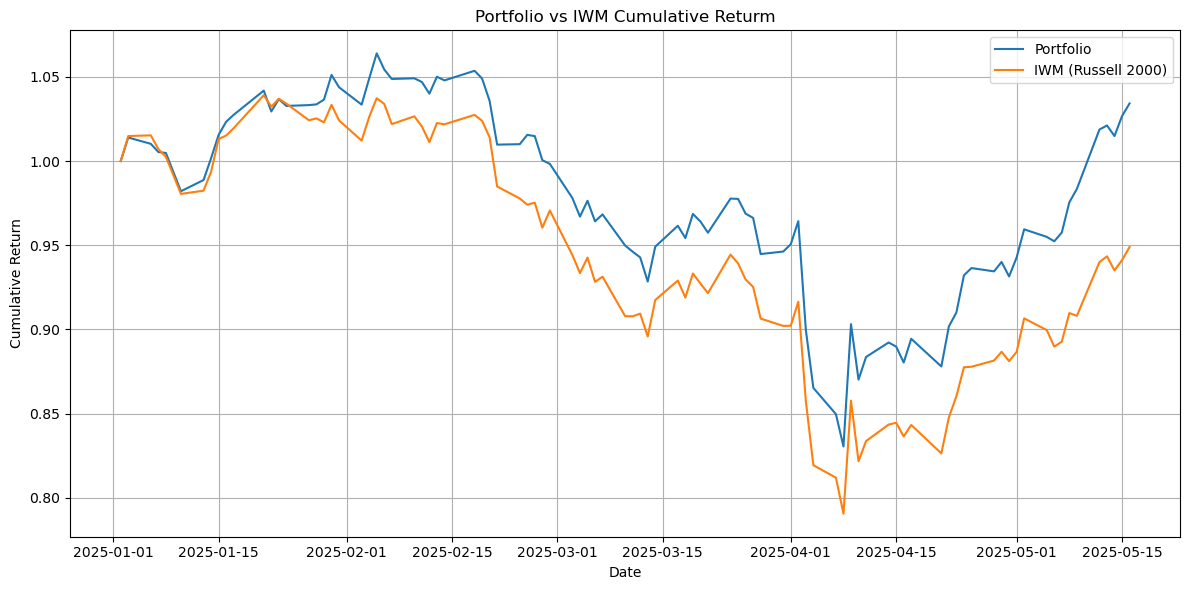

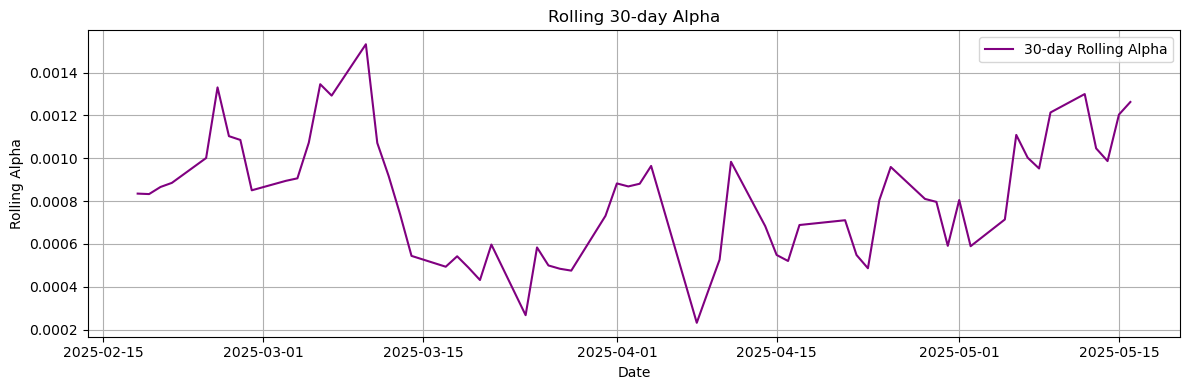

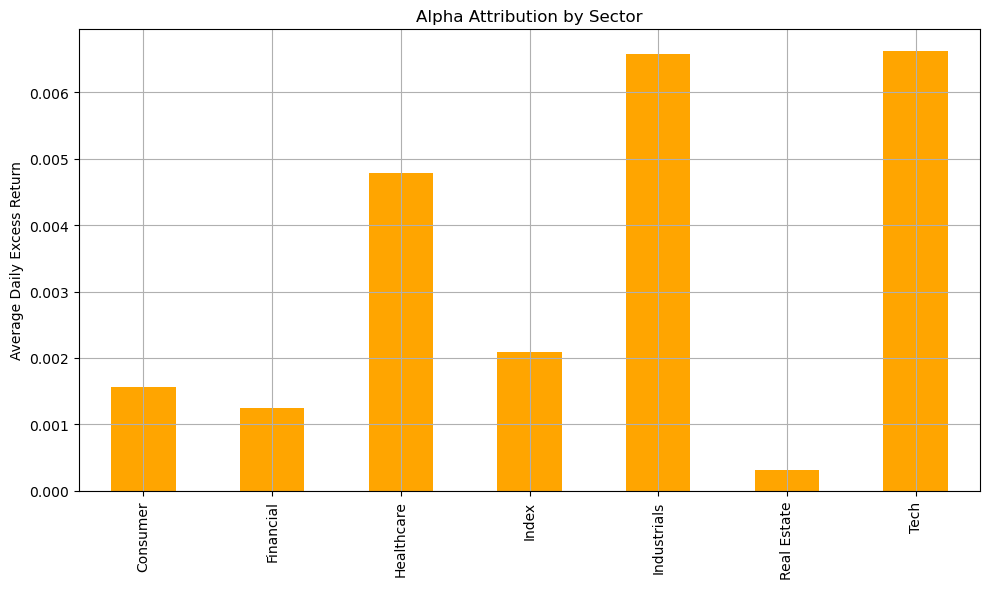

In [ ]:
# Portfolio vs Benchmark with Alpha
plt.figure(figsize=(12, 6))
plt.plot(portfolio_cum, label='Portfolio')
plt.plot(benchmark_cum, label='IWM (Russell 2000)')
plt.title('Portfolio vs IWM Cumulative Returm')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Rolling Alpha Plot
plt.figure(figsize=(12, 4))
plt.plot(rolling_alpha, label='30-day Rolling Alpha', color='purple')
plt.title('Rolling 30-day Alpha')
plt.xlabel('Date')
plt.ylabel('Rolling Alpha')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Alpha Attribution Bar Chart
plt.figure(figsize=(10, 6))
sector_contributions.plot(kind='bar', color='orange')
plt.title('Alpha Attribution by Sector')
plt.ylabel('Average Daily Excess Return')
plt.grid(True)
plt.tight_layout()
plt.show()

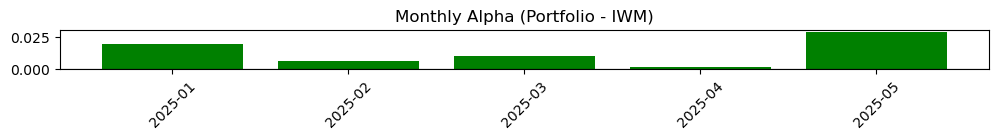

In [ ]:
monthly_alpha = alpha_line.resample('M').last() - alpha_line.resample('M').first()
monthly_alpha.index = monthly_alpha.index.strftime('%Y-%m')

# Convert to DataFrame for heatmap-like display
alpha_df = pd.DataFrame(monthly_alpha, columns=['Alpha'])

plt.figure(figsize=(10, 1.5))
colors = alpha_df['Alpha'].apply(lambda x: 'green' if x > 0 else 'red')
plt.bar(alpha_df.index, alpha_df['Alpha'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45)
plt.title('Monthly Alpha (Portfolio - IWM)')
plt.tight_layout()
plt.show()

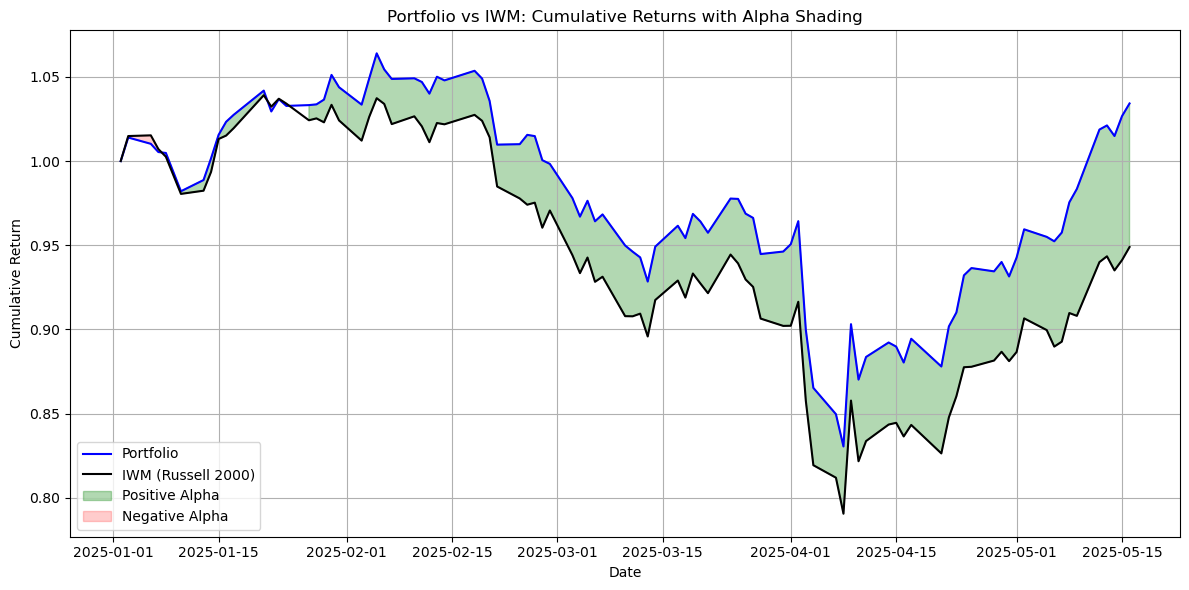

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(portfolio_cum, label='Portfolio', color='blue')
plt.plot(benchmark_cum, label='IWM (Russell 2000)', color='black')

# Fill the area between the portfolio and benchmark
plt.fill_between(portfolio_cum.index, portfolio_cum, benchmark_cum,
                 where=(portfolio_cum > benchmark_cum),
                 color='green', alpha=0.3, label='Positive Alpha')
plt.fill_between(portfolio_cum.index, portfolio_cum, benchmark_cum,
                 where=(portfolio_cum <= benchmark_cum),
                 color='red', alpha=0.2, label='Negative Alpha')

plt.title('Portfolio vs IWM: Cumulative Returns with Alpha Shading')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


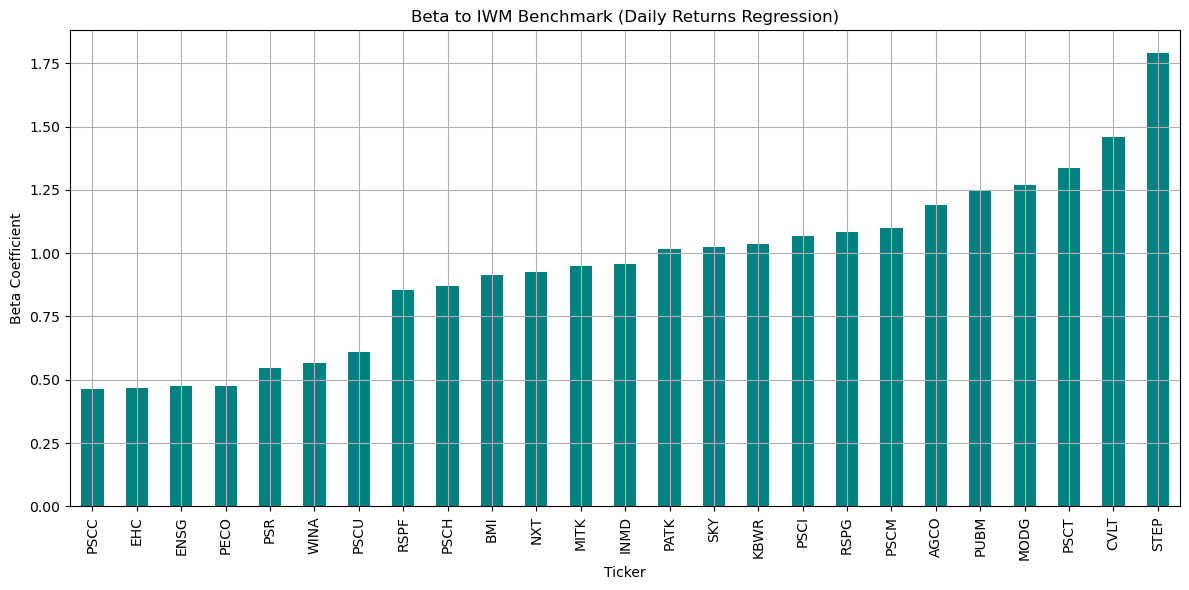

In [ ]:
import statsmodels.api as sm

returns = prices_data.pct_change()
benchmark_returns = rut_series.pct_change()

returns = returns.loc[benchmark_returns.index]
benchmark_returns = benchmark_returns.loc[returns.index]

index_tickers = {'PSCI', 'PSCT', 'PSCM', 'PSCU', 'RSPG', 'RSPF', 'PSR', 'KBWR', 'PSCC', 'PSCH'}
bar_colors = 'teal'

betas = {}

for ticker in returns.columns:
    X = sm.add_constant(benchmark_returns)  # adds alpha
    y = returns[ticker]
    model = sm.OLS(y, X, missing='drop').fit()
    betas[ticker] = model.params[1]

beta_df = pd.Series(betas).sort_values()

plt.figure(figsize=(12, 6))
beta_df.plot(kind='bar', color=bar_colors)
plt.title('Beta to IWM Benchmark (Daily Returns Regression)')
plt.ylabel('Beta Coefficient')
plt.xlabel('Ticker')
plt.grid(True)
plt.tight_layout()
plt.show()


#### Other ideas: 

Add metrics for Factor risk exposure, overall portfolio risk, optimal position sizing 
Indifference to index weightings → only investment attractiveness should matter  
